<a href="https://colab.research.google.com/github/vseetharama/BCDL606-ML-lab/blob/main/allcode.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Lab1**

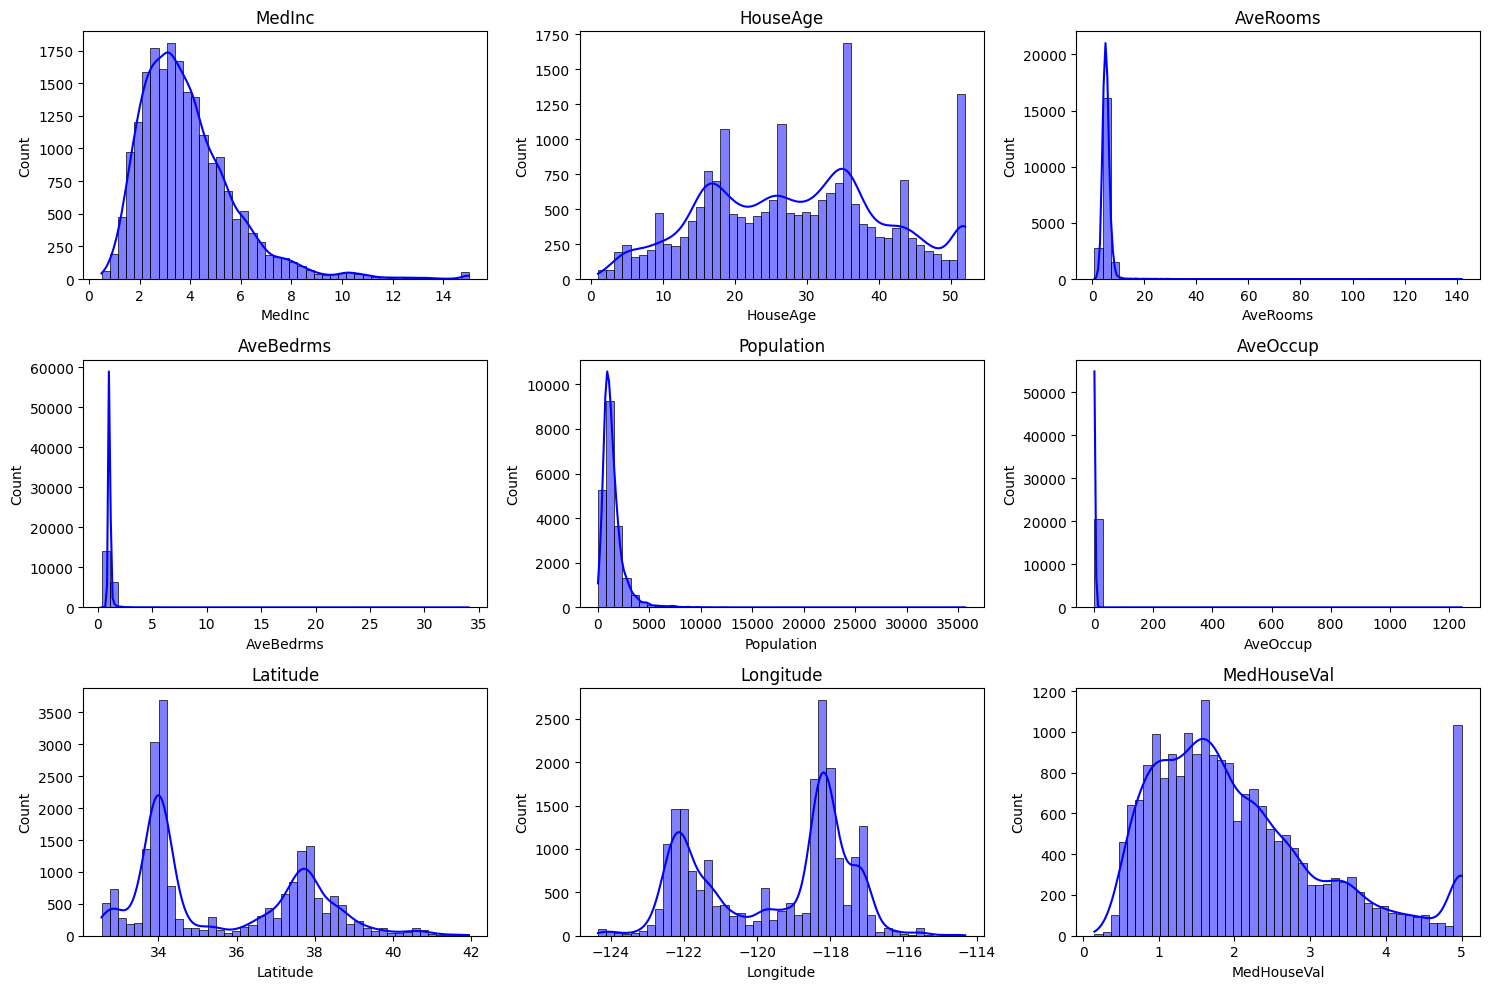

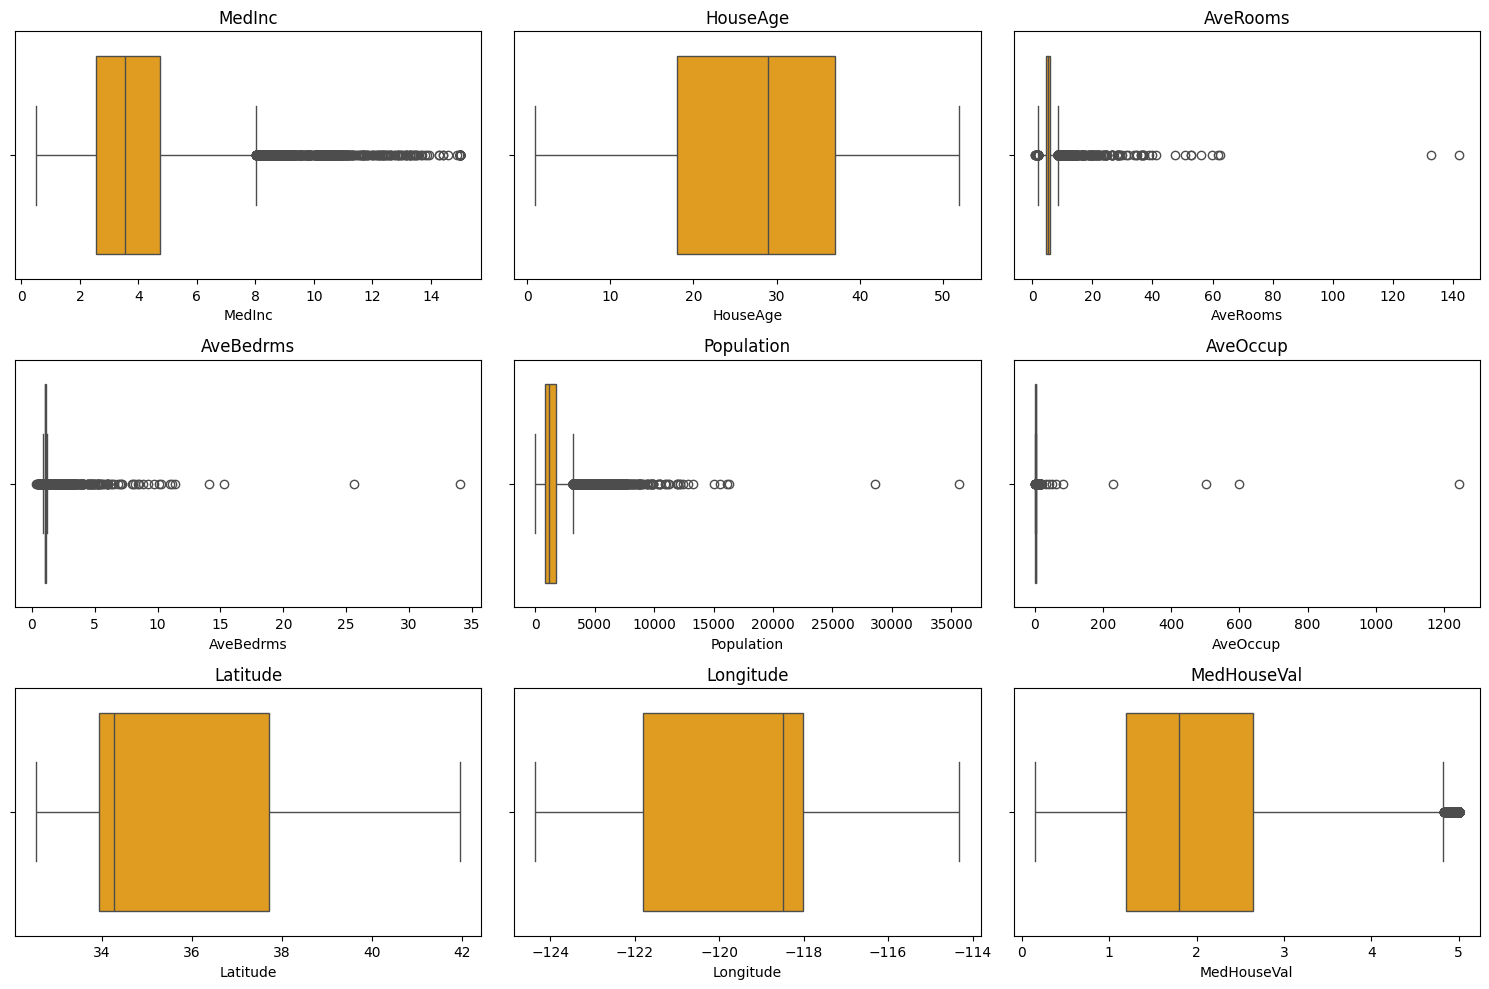

Outliers count:
{'MedInc': 681, 'HouseAge': 0, 'AveRooms': 511, 'AveBedrms': 1424, 'Population': 1196, 'AveOccup': 711, 'Latitude': 0, 'Longitude': 0, 'MedHouseVal': 1071}
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude   MedHouseVal  
count  20640.000000  20640.000000  20640.000000  206

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load California Housing dataset
df = fetch_california_housing(as_frame=True).frame

# Select numerical columns
cols = df.select_dtypes(include=np.number).columns

# -------- Histograms --------
plt.figure(figsize=(15,10))
for i in range(len(cols)):
    plt.subplot(3,3,i+1)
    sns.histplot(df[cols[i]], kde=True, bins=45, color='blue')
    plt.title(cols[i])
plt.tight_layout()
plt.show()

# -------- Boxplots --------
plt.figure(figsize=(15,10))
for i in range(len(cols)):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[cols[i]], color='orange')
    plt.title(cols[i])
plt.tight_layout()
plt.show()

# -------- Outlier Detection (IQR Method) --------
print("Outliers count:")

outliers_summary = {}

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
    outliers_summary[col] = count

print(outliers_summary)

# -------- Summary Statistics --------
print(df.describe())

**Lab2**

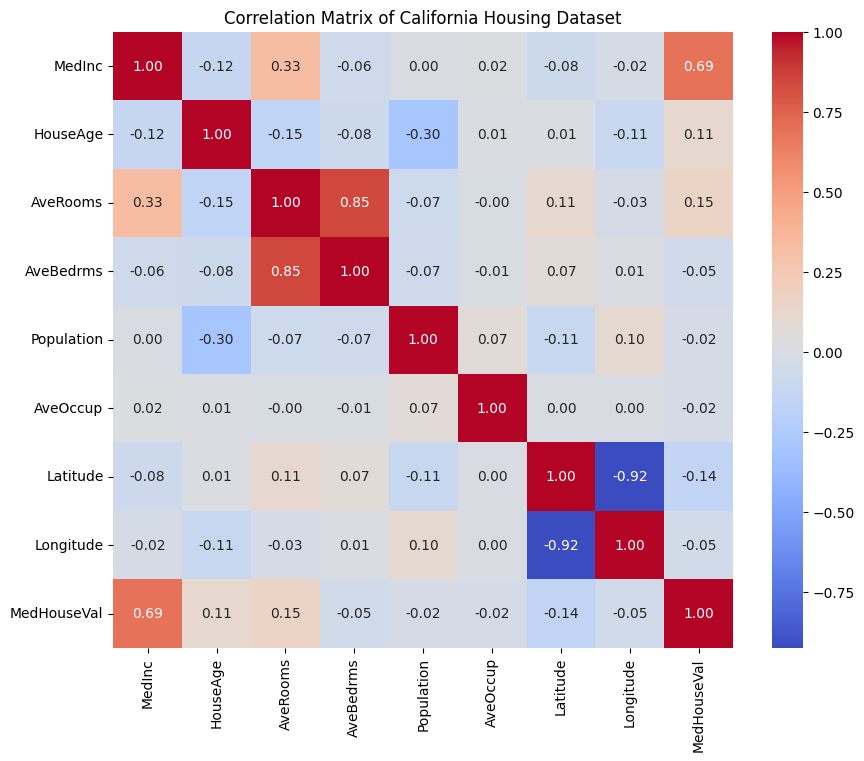

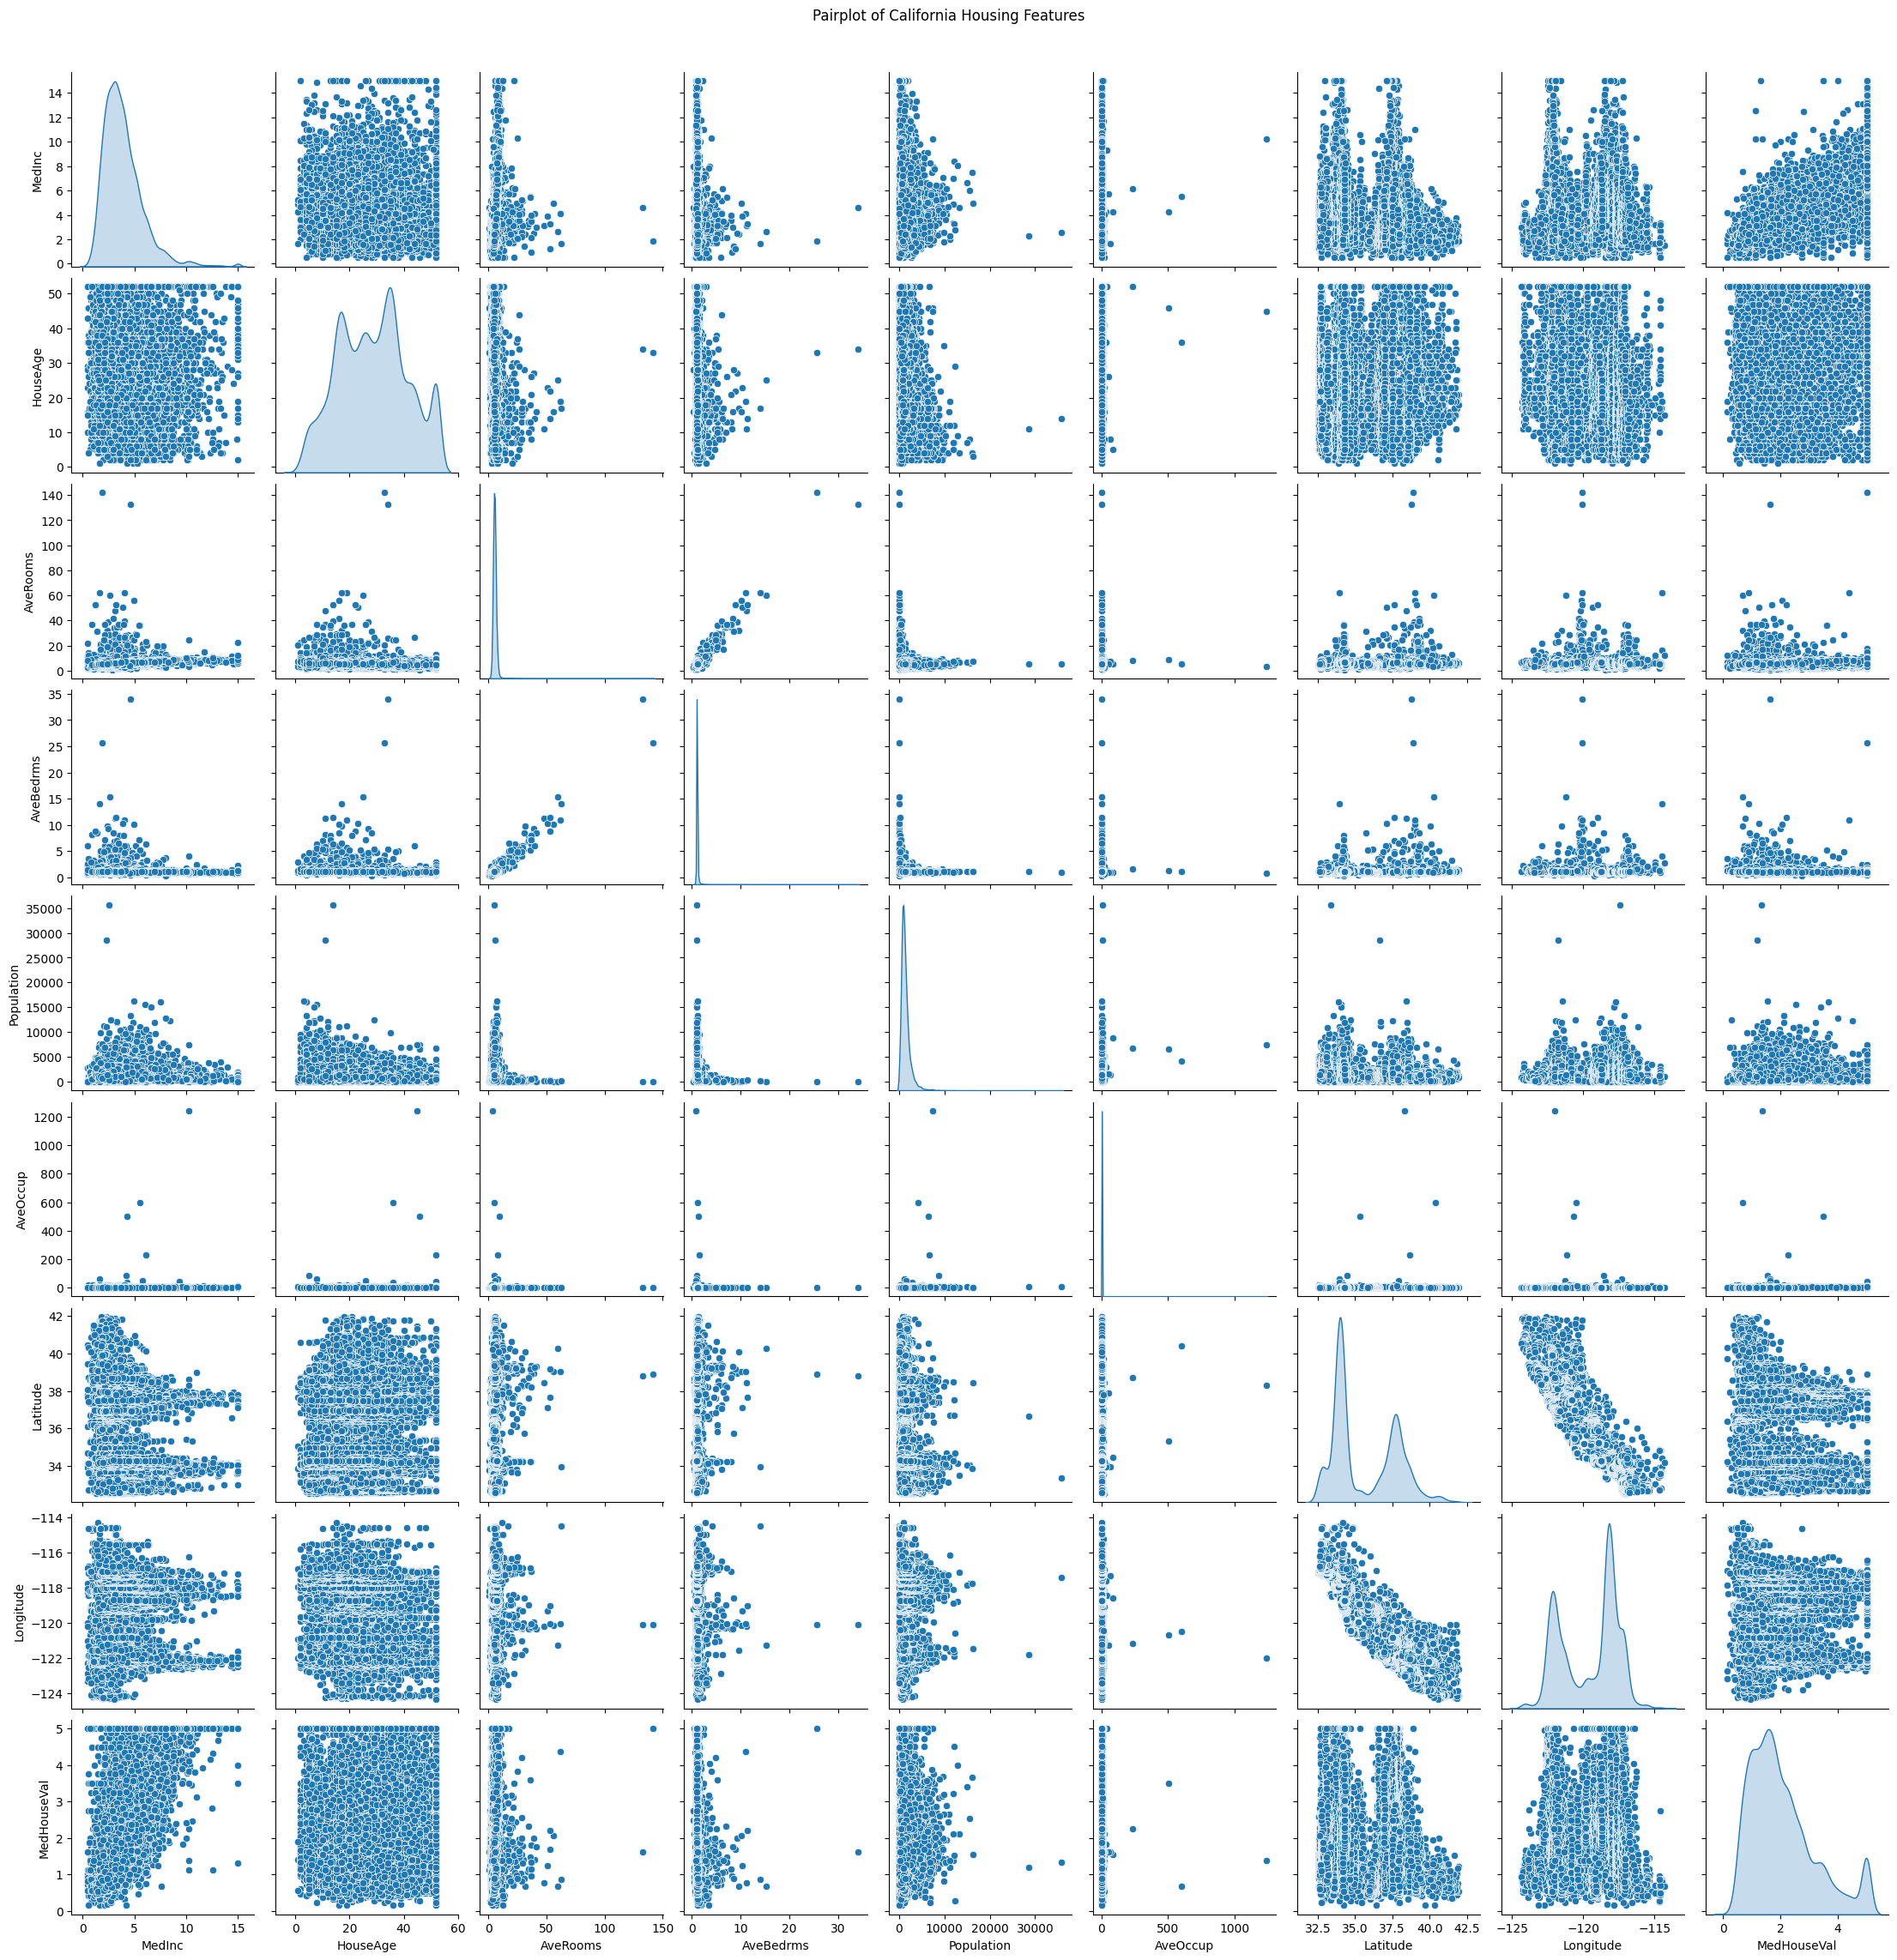

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing

# Load California Housing dataset
data = fetch_california_housing(as_frame=True).frame

# -------- Correlation Matrix --------
correlation_matrix = data.corr()

# -------- Heatmap --------
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix of California Housing Dataset")
plt.show()

# -------- Pairplot --------
sns.pairplot(data, diag_kind='kde')
plt.suptitle("Pairplot of California Housing Features", y=1.02)
plt.show()

**Lab3**

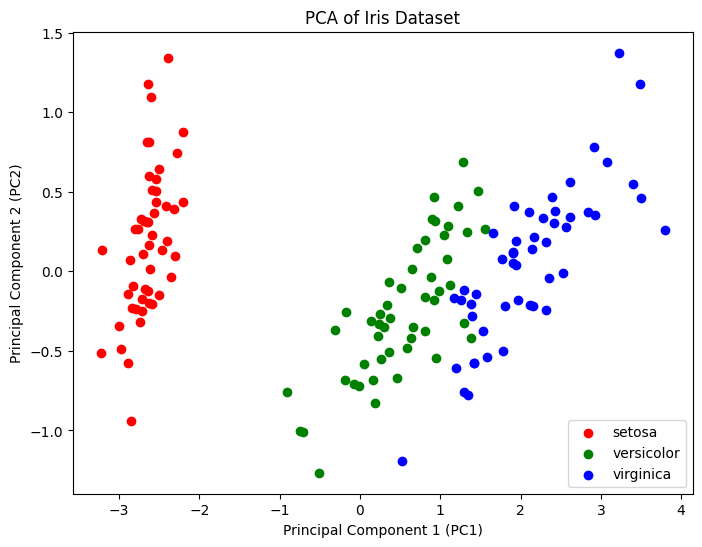

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA

# Load Iris dataset
iris = load_iris()
data = iris.data
target = iris.target
labels = iris.target_names

# Apply PCA (reduce to 2 components)
pca = PCA(n_components=2)
data_reduced = pca.fit_transform(data)

# Create DataFrame for visualization
df = pd.DataFrame(data_reduced, columns=['PC1', 'PC2'])
df['target'] = target

# Plot PCA result
plt.figure(figsize=(8,6))
colors = ['red', 'green', 'blue']

for i in range(3):
    plt.scatter(df[df['target']==i]['PC1'],
                df[df['target']==i]['PC2'],
                c=colors[i],
                label=labels[i])

plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.title("PCA of Iris Dataset")
plt.legend()
plt.show()

Lab4

In [ ]:
import pandas as pd
import numpy as np

data = pd.read_csv("Lab4.csv")

attributes = np.array(data)[:, :-1]
target = np.array(data)[:, -1]
print("Training dataset")
print(data)
def find_s(attributes, target):
    hypothesis = ['?' for _ in range(attributes.shape[1])]

    for i in range(len(target)):
        if target[i] == "Yes":
            hypothesis = attributes[i].copy()
            break

    for i in range(len(attributes)):
        if target[i] == "Yes":
            for j in range(len(hypothesis)):
                if hypothesis[j] != attributes[i][j]:
                    hypothesis[j] = '?'
                    # print(hypothesis)
    return hypothesis
print("final hypothiese")
print(find_s(attributes, target))

Training dataset
     Sky  Temp Humidity    Wind Water Forecast EnjoySport
0  Sunny  Warm   Normal  Strong  Warm     Same        Yes
1  Sunny  Warm     High  Strong  Warm     Same        Yes
2  Rainy  Cold     High  Strong  Warm   Change         No
3  Sunny  Warm     High  Strong  Cool   Change        Yes
final hypothiese
['Sunny' 'Warm' '?' 'Strong' '?' '?']


**Lab5**


In [ ]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

# Generate 100 random values between 0 and 1
data = np.random.rand(100).reshape(-1,1)

# Label first 50 values
labels = np.array(["Class1" if x <= 0.5 else "Class2" for x in data[:50]])

# Split into training and testing
X_train = data[:50]
y_train = labels
X_test = data[50:]

# Different k values
k_values = [1,2,3,4,5,20,30]

# Apply KNN
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    print(f"\nResults for k = {k}:")
    print(predictions)


Results for k = 1:
['Class1' 'Class2' 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class2' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2'
 'Class2' 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class2'
 'Class1' 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1'
 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class2' 'Class1'
 'Class2' 'Class2' 'Class2' 'Class2' 'Class2' 'Class2' 'Class1' 'Class2'
 'Class2' 'Class1']

Results for k = 2:
['Class1' 'Class2' 'Class2' 'Class2' 'Class2' 'Class1' 'Class2' 'Class2'
 'Class2' 'Class1' 'Class1' 'Class2' 'Class1' 'Class1' 'Class1' 'Class2'
 'Class2' 'Class1' 'Class1' 'Class1' 'Class1' 'Class2' 'Class2' 'Class2'
 'Class1' 'Class1' 'Class1' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1'
 'Class2' 'Class2' 'Class1' 'Class2' 'Class1' 'Class2' 'Class1' 'Class1'
 'Class2' 'Class2' 'Class2' 'Class2' 'Class2' 'Class2' 'Class1' 'Class2'
 'Class2' 'Class1']

Results for k = 3:
['Class1' 'Class2' 'Clas

**Lab6**


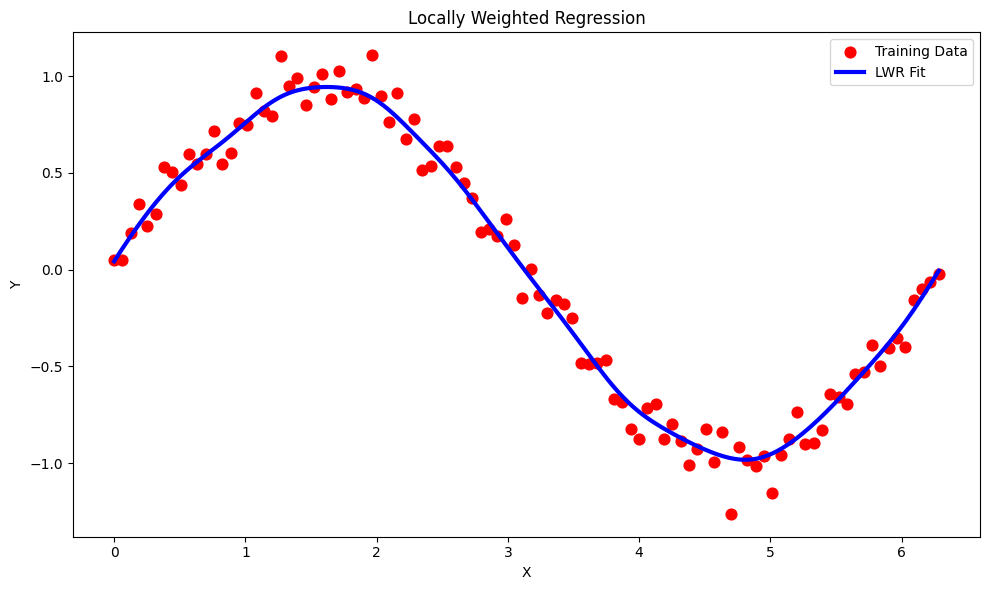

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.nonparametric.kernel_regression import KernelReg

# Generate data
np.random.seed(42)

X = np.linspace(0, 2*np.pi, 100)
y = np.sin(X) + 0.1*np.random.randn(100)

# Train LWR model
model = KernelReg(y, X, 'c')

# Test data
x_test = np.linspace(0, 2*np.pi, 200)

# Predict values
y_pred, _ = model.fit(x_test)

# Plot graph
plt.figure(figsize=(10,6))

plt.scatter(X, y,
            color='red',
            s=60,
             # alpha=0.7,
            label="Training Data")

plt.plot(x_test, y_pred,
         color='blue',
         linewidth=3,
         label="LWR Fit")

plt.title("Locally Weighted Regression")
plt.xlabel("X")
plt.ylabel("Y")

plt.legend()
plt.tight_layout()

plt.show()

**Lab7**

<>:85: SyntaxWarning: invalid escape sequence '\s'
<>:85: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2803/1067566523.py:85: SyntaxWarning: invalid escape sequence '\s'
  sep="\s+",


Demonstrating Linear Regression and Polynomial Regression



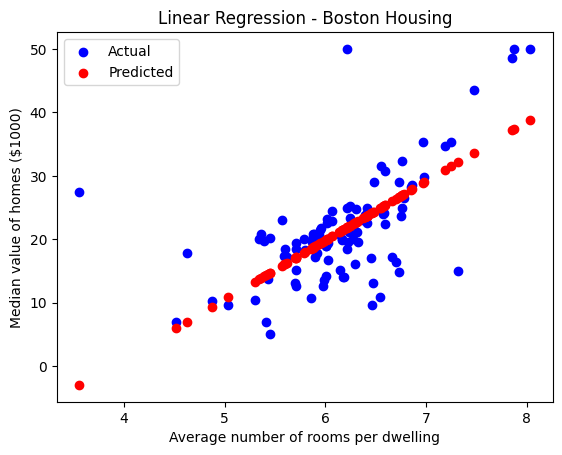

Linear Regression - Boston Housing Dataset
Mean Squared Error: 46.144775347317264
R2 Score: 0.3707569232254778


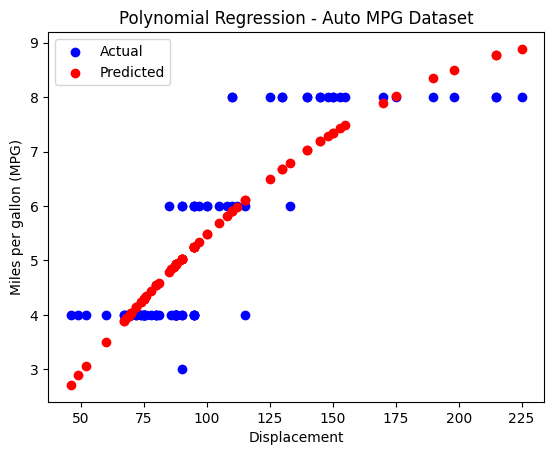

Polynomial Regression - Auto MPG Dataset
Mean Squared Error: 0.7431490557205879
R2 Score: 0.7505650609469621


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error, r2_score


# -------- Linear Regression (Boston Housing Dataset) --------

def linear_regression_boston():

    # Load dataset
    url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

    df = pd.read_csv(url)

    # Select feature and target
    X = df[["rm"]].values
    y = df["medv"].values

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Create model
    model = LinearRegression()

    # Train model
    model.fit(X_train, y_train)

    # Predict values
    y_pred = model.predict(X_test)

    # Plot graph
    plt.scatter(X_test, y_test,
                color="blue",
                label="Actual")

    plt.scatter(X_test, y_pred,
                color="red",
                label="Predicted")

    plt.xlabel("Average number of rooms per dwelling")
    plt.ylabel("Median value of homes ($1000)")
    plt.title("Linear Regression - Boston Housing")

    plt.legend()
    plt.show()

    # Evaluation
    print("Linear Regression - Boston Housing Dataset")

    print("Mean Squared Error:",
          mean_squared_error(y_test, y_pred))

    print("R2 Score:",
          r2_score(y_test, y_pred))


# -------- Polynomial Regression (Auto MPG Dataset) --------

def polynomial_regression_auto_mpg():

    # Load dataset
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"

    column_names = [
        "mpg",
        "cylinders",
        "displacement",
        "horsepower",
        "weight",
        "acceleration",
        "model_year",
        "origin"
    ]

    data = pd.read_csv(
        url,
        sep="\s+",
        names=column_names,
        na_values='?'
    )

    # Remove missing values
    data = data.dropna()

    # Select feature and target
    X = data["displacement"].values.reshape(-1,1)
    y = data["mpg"].values

    # Split dataset
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Create polynomial regression model
    poly_model = make_pipeline(
        PolynomialFeatures(degree=2),
        LinearRegression()
    )

    # Train model
    poly_model.fit(X_train, y_train)

    # Predict values
    y_pred = poly_model.predict(X_test)

    # Plot graph
    plt.scatter(X_test, y_test,
                color="blue",
                label="Actual")

    plt.scatter(X_test, y_pred,
                color="red",
                label="Predicted")

    plt.xlabel("Displacement")
    plt.ylabel("Miles per gallon (MPG)")
    plt.title("Polynomial Regression - Auto MPG Dataset")

    plt.legend()
    plt.show()

    # Evaluation
    print("Polynomial Regression - Auto MPG Dataset")

    print("Mean Squared Error:",
          mean_squared_error(y_test, y_pred))

    print("R2 Score:",
          r2_score(y_test, y_pred))


# -------- Main Function --------

if __name__ == "__main__":

    print("Demonstrating Linear Regression and Polynomial Regression\n")

    linear_regression_boston()

    polynomial_regression_auto_mpg()

**Lab8**

Model trained Successfully...


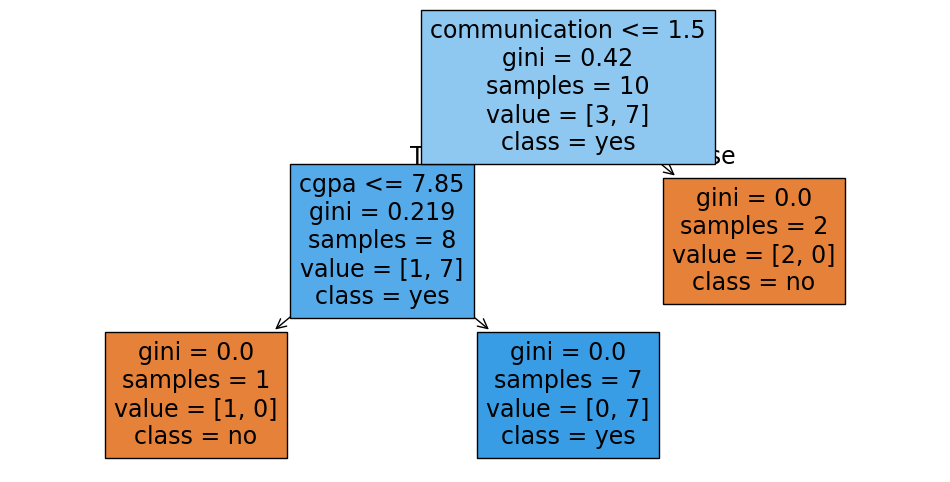

Prediction: yes


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder

# Train Breast Cancer model
cancer = load_breast_cancer()

model = DecisionTreeClassifier(max_depth=9)

model.fit(cancer.data, cancer.target)

print("Model trained Successfully...")

# Sample dataset
data = pd.DataFrame({
    'cgpa':[9.2,8.5,9.0,7.5,8.2,9.1,7.8,9.3,8.4,8.6],
    'interactiveness':['yes','no','no','no','yes','yes','yes','yes','no','yes'],
    'practical_knowledge':['verygood','good','average','average','good',
                           'good','good','verygood','good','average'],
    'communication':['good','moderate','poor','good','moderate',
                     'moderate','poor','good','good','good'],
    'job_offer':['yes','yes','no','no','yes',
                 'yes','no','yes','yes','yes']
})

# Encode categorical columns
le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()

data['interactiveness'] = le1.fit_transform(data['interactiveness'])
data['practical_knowledge'] = le2.fit_transform(data['practical_knowledge'])
data['communication'] = le3.fit_transform(data['communication'])
data['job_offer'] = le4.fit_transform(data['job_offer'])

# Features and target
X = data.drop('job_offer', axis=1)
y = data['job_offer']

# Train Decision Tree
tree = DecisionTreeClassifier(max_depth=4)

tree.fit(X, y)

# Plot tree
plt.figure(figsize=(12,6))

plot_tree(tree,
          filled=True,
          feature_names=X.columns,
          class_names=le4.classes_)

plt.show()

# Test sample
test = pd.DataFrame([{
    'cgpa':8.5,
    'interactiveness':'yes',
    'practical_knowledge':'good',
    'communication':'good'
}])

# Encode test sample
test['interactiveness'] = le1.transform(test['interactiveness'])
test['practical_knowledge'] = le2.transform(test['practical_knowledge'])
test['communication'] = le3.transform(test['communication'])

# Predict
pred = tree.predict(test)

print("Prediction:", le4.inverse_transform(pred)[0])

**Lab9**

Accuracy: 80.83333333333333 %

Classification Report:

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      1.00      1.00         2
           2       0.33      0.67      0.44         3
           3       0.00      0.00      0.00         5
           4       1.00      0.50      0.67         4
           5       1.00      1.00      1.00         2
           7       1.00      0.75      0.86         4
           8       1.00      0.67      0.80         3
           9       1.00      0.75      0.86         4
          10       1.00      1.00      1.00         3
          11       1.00      1.00      1.00         1
          12       0.40      1.00      0.57         4
          13       1.00      0.80      0.89         5
          14       1.00      0.40      0.57         5
          15       0.67      1.00      0.80         2
          16       1.00      0.67      0.80         3
          17       1.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


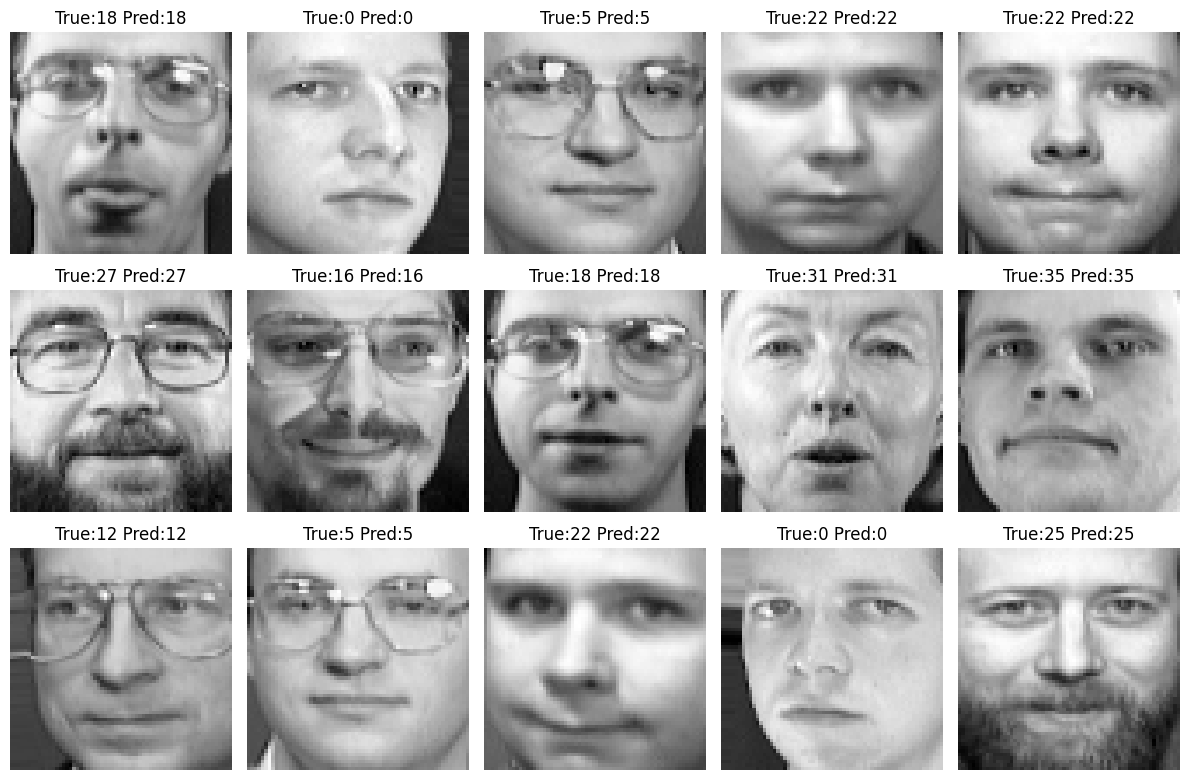

In [ ]:
from sklearn.datasets import fetch_olivetti_faces
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

# Load dataset
data = fetch_olivetti_faces(shuffle=True, random_state=42)

X = data.data
y = data.target

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

# Train model
model = GaussianNB()

model.fit(X_train, y_train)

# Predict values
y_pred = model.predict(X_test)

# Accuracy
print("Accuracy:",
      accuracy_score(y_test, y_pred) * 100, "%")

# Classification Report
print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

# Confusion Matrix
print("\nConfusion Matrix:\n")

print(confusion_matrix(y_test, y_pred))

# Display images
fig, axes = plt.subplots(3, 5, figsize=(12,8))

for ax, img, true, pred in zip(
        axes.ravel(),
        X_test,
        y_test,
        y_pred):

    ax.imshow(img.reshape(64,64), cmap='gray')

    ax.set_title(f"True:{true} Pred:{pred}")

    ax.axis('off')

plt.tight_layout()

plt.show()

**Lab10**

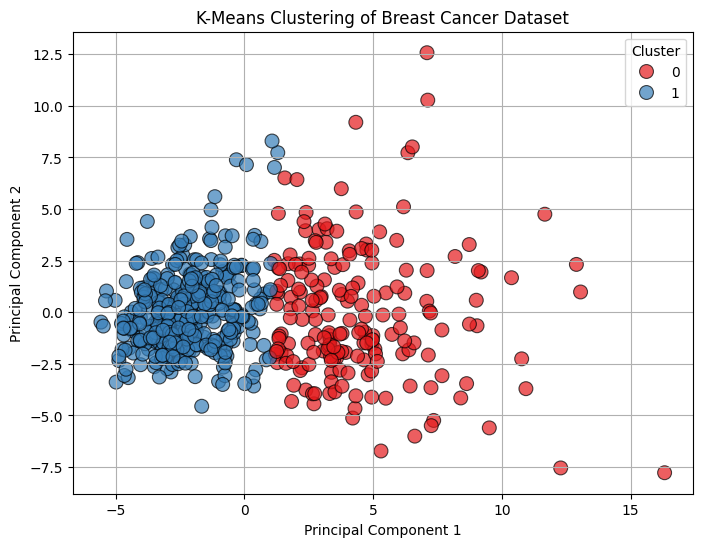

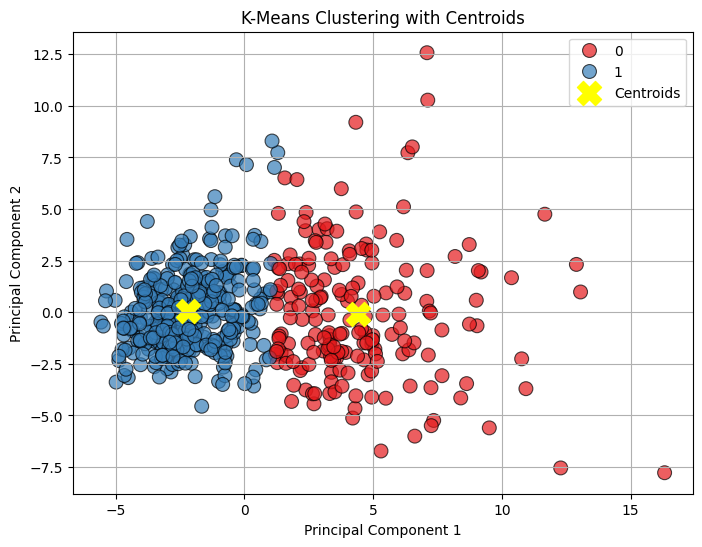

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load dataset
data = load_breast_cancer()

X = data.data

# Scale data
X = StandardScaler().fit_transform(X)

# Apply K-Means
kmeans = KMeans(n_clusters=2, random_state=42)

clusters = kmeans.fit_predict(X)

# Apply PCA
X_pca = PCA(n_components=2).fit_transform(X)

# Create DataFrame
df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

df['Cluster'] = clusters

# Plot clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,
    edgecolor='black',
    alpha=0.7
)

plt.title("K-Means Clustering of Breast Cancer Dataset")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(True)

plt.show()

# Plot clusters with centroids
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Cluster',
    data=df,
    palette='Set1',
    s=100,
    edgecolor='black',
    alpha=0.7
)

# Centroids
centers = PCA(n_components=2).fit(X).transform(
    kmeans.cluster_centers_
)

plt.scatter(
    centers[:,0],
    centers[:,1],
    c='yellow',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title("K-Means Clustering with Centroids")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend()

plt.grid(True)

plt.show()